## `algo_1` vs `algo_2` by arrival slippage / IS slippage.
- Arrival slippage measures how the execution price compares to the market midpoint when the order first arrived. For a buy order, paying above the arrival mid is bad; for a sell order, selling below the arrival mid is bad.
- Lower slippage means better execution relative to the market mid-price when the order arrived. 

The goal is to compare raw performance and then assess performance after accounting for order difficulty.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("TCA_problem.csv")

# drop the extra index-like column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()

(40000, 7)


,IS_Slippage,ordersize,volatility,averageSpread,duration,notional,algo
0,118.374496,28.154509,150,2.638797,0.997847,1.981122e+08,algo_2
1,368.606221,193.324306,300,4.264819,1.000000,1.077540e+07,algo_2
2,356.180923,46.862604,300,1.954701,1.000000,2.647122e+07,algo_2
3,110.203046,49.780591,100,6.334067,0.941159,2.929402e+07,algo_1
4,-39.989627,7.890752,300,1.691854,1.000000,2.162974e+08,algo_2


In [2]:
print(df.describe())
print('-------------------------------------------------------------------------')
print()
print(df.isna().sum())
print('-----------------------------------------------------------------------------------------------------------------')

summary = df.groupby("algo").agg(
    n_orders=("IS_Slippage", "size"),
    mean_IS=("IS_Slippage", "mean"),
    median_IS=("IS_Slippage", "median"),
    std_IS=("IS_Slippage", "std"),
    mean_notional=("notional", "mean"),
    median_notional=("notional", "median"),
    mean_ordersize=("ordersize", "mean"),
    median_ordersize=("ordersize", "median"),
)
print()
print(summary)

        IS_Slippage     ordersize    volatility  averageSpread      duration  \
count  40000.000000  40000.000000  40000.000000   40000.000000  40000.000000   
mean     223.879454     72.099398    199.985000       4.432733      0.702325   
std      197.737593    114.586833     70.690344       5.727878      0.271583   
min     -450.978358      0.462115    100.000000       0.052149      0.000383   
25%       93.521857     16.664334    150.000000       1.367493      0.521417   
50%      187.259593     36.791575    200.000000       2.709871      0.772083   
75%      318.996357     82.278912    250.000000       5.242029      0.939186   
max     2433.721410   3286.605211    300.000000     172.026282      1.000000   

           notional  
count  4.000000e+04  
mean   3.434024e+07  
std    1.173464e+08  
min    8.166798e+04  
25%    1.023405e+07  
50%    2.027968e+07  
75%    3.968378e+07  
max    1.368619e+10  
-------------------------------------------------------------------------

IS_Sli

## 1. How would you compare the IS slippage of `algo_1` and `algo_2`？Which one do you think performs better (smaller IS slippage)? Why?

- I first compare the two algos using average and median IS slippage.
- Since lower slippage is better, the algo with smaller mean/median appears better on a raw basis.
- I also examine the distribution because averages alone may be distorted by outliers or skew.

In [3]:
q1_stats = df.groupby("algo")["IS_Slippage"].agg(["count", "mean", "median", "std", "min", "max"])
print(q1_stats)

        count        mean      median         std         min          max
algo                                                                      
algo_1  20000  203.833125  172.713069  185.341458 -450.978358  1980.084979
algo_2  20000  243.925783  203.398346  207.477854 -423.340438  2433.721410


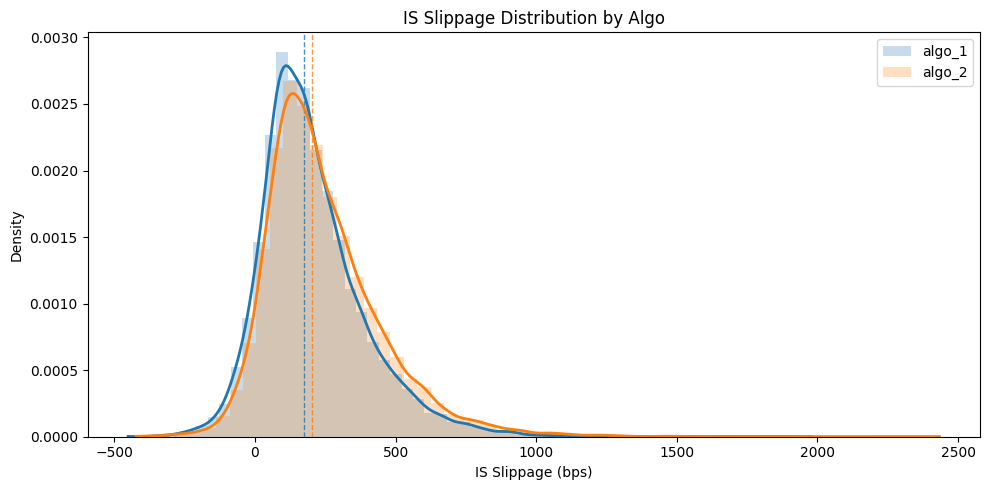

In [4]:
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.tab10.colors  # up to 10 algos

for i, (algo_name, sub) in enumerate(df.groupby("algo")):
    data = sub["IS_Slippage"].dropna()
    color = colors[i % len(colors)]
    
    # Histogram (normalized to density so KDE is on same scale)
    ax.hist(data, bins=60, alpha=0.25, density=True, color=color, label=algo_name)
    
    # KDE overlay
    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2)
    
    # Optional: mark the median
    ax.axvline(data.median(), color=color, linestyle="--", linewidth=1, alpha=0.8)

ax.set_xlabel("IS Slippage (bps)")
ax.set_ylabel("Density")
ax.set_title("IS Slippage Distribution by Algo")
ax.legend()
plt.tight_layout()
plt.show()

On a raw unconditional basis, **`algo_1` appears to perform better**, having lower average and median IS slippage while also centering around this lower IS with smaller variance. However, **this comparison may not be fully fair** if the two algos are assigned different types of orders.

## 2. Compute the notional weighted IS slippage of both algos. How would you interpret this number? What is its economic interpretation? How would you measure a single order's contribution to the notional weighted average?

- The notional-weighted IS slippage measures execution cost per unit of traded money. 
- It is more economically meaningful than a simple average across orders because each order may be of different sizes of capital. Large orders represent more capital and therefore naturally should contribute more to the final performance measure. 
- A single order’s contribution equals its notional weight times its slippage.

In [5]:
df['algo_total_notional'] = df.groupby('algo')['notional'].transform('sum')
df['IS_weighted_contribution'] = df['IS_Slippage'] * df['notional'] / df['algo_total_notional']

df.head()

,IS_Slippage,ordersize,volatility,averageSpread,duration,notional,algo,algo_total_notional,IS_weighted_contribution
0,118.374496,28.154509,150,2.638797,0.997847,1.981122e+08,algo_2,7.164690e+11,0.032732
1,368.606221,193.324306,300,4.264819,1.000000,1.077540e+07,algo_2,7.164690e+11,0.005544
2,356.180923,46.862604,300,1.954701,1.000000,2.647122e+07,algo_2,7.164690e+11,0.013160
3,110.203046,49.780591,100,6.334067,0.941159,2.929402e+07,algo_1,6.571406e+11,0.004913
4,-39.989627,7.890752,300,1.691854,1.000000,2.162974e+08,algo_2,7.164690e+11,-0.012073


In [6]:
notional_weighted_summary = df.groupby('algo').agg(
    total_notional=('notional', 'sum'),
    notional_weighted_avg_IS_bps=('IS_weighted_contribution', 'sum'),
)
print(notional_weighted_summary)

        total_notional  notional_weighted_avg_IS_bps
algo                                                
algo_1    6.571406e+11                    207.300834
algo_2    7.164690e+11                    371.652034


The IS weighted contribution represents each trade's slippage scaled by the trade's notional relative to the algo's total notional. Thus, **the notional weighted average IS, the sum of the contributions, measures the average execution shortfall experienced by each dollar of traded notional**. Since `algo_1` has a smaller weighted average IS, **`algo_1` is again better by raw comparison**.

Both algos see an increase from its simple average IS to its notional weighted average IS. This points to the fact that **on larger orders (larger notional), the algos tend to have larger slippages**. This phenomenon is more pronounced in `algo_2`, as reflected by a much larger increase.

## 3. Plot and describe the disitrbution of the 'features'. i.e. Volatility, Average Spread, Order Size and Duration.

- Notionals/Trade volumes still may not tell the whole story since the algos may be assigned orders of different difficulties, which can be reflected via 'features'.

In [7]:
features = ["volatility", "averageSpread", "ordersize", "duration"]

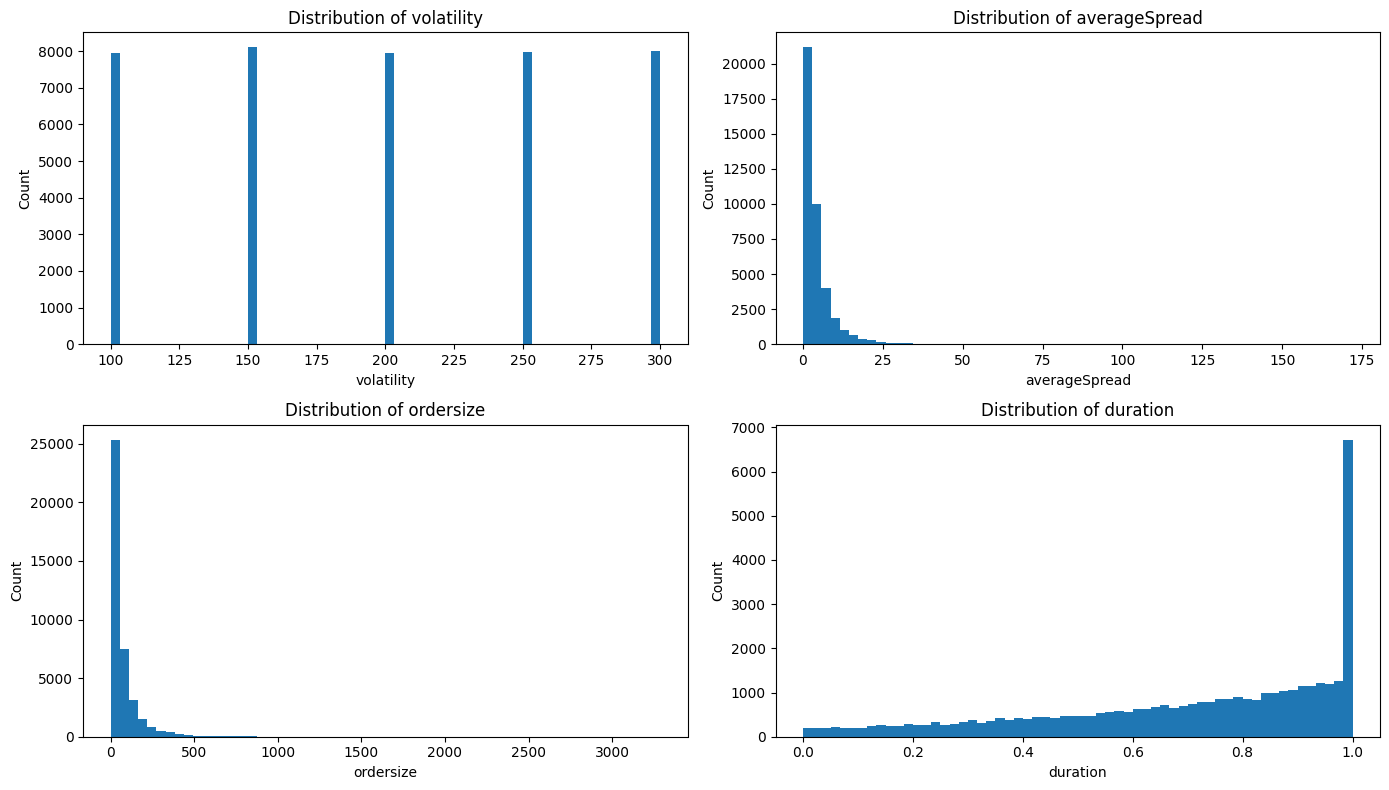

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    ax.hist(df[feat], bins=60)
    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

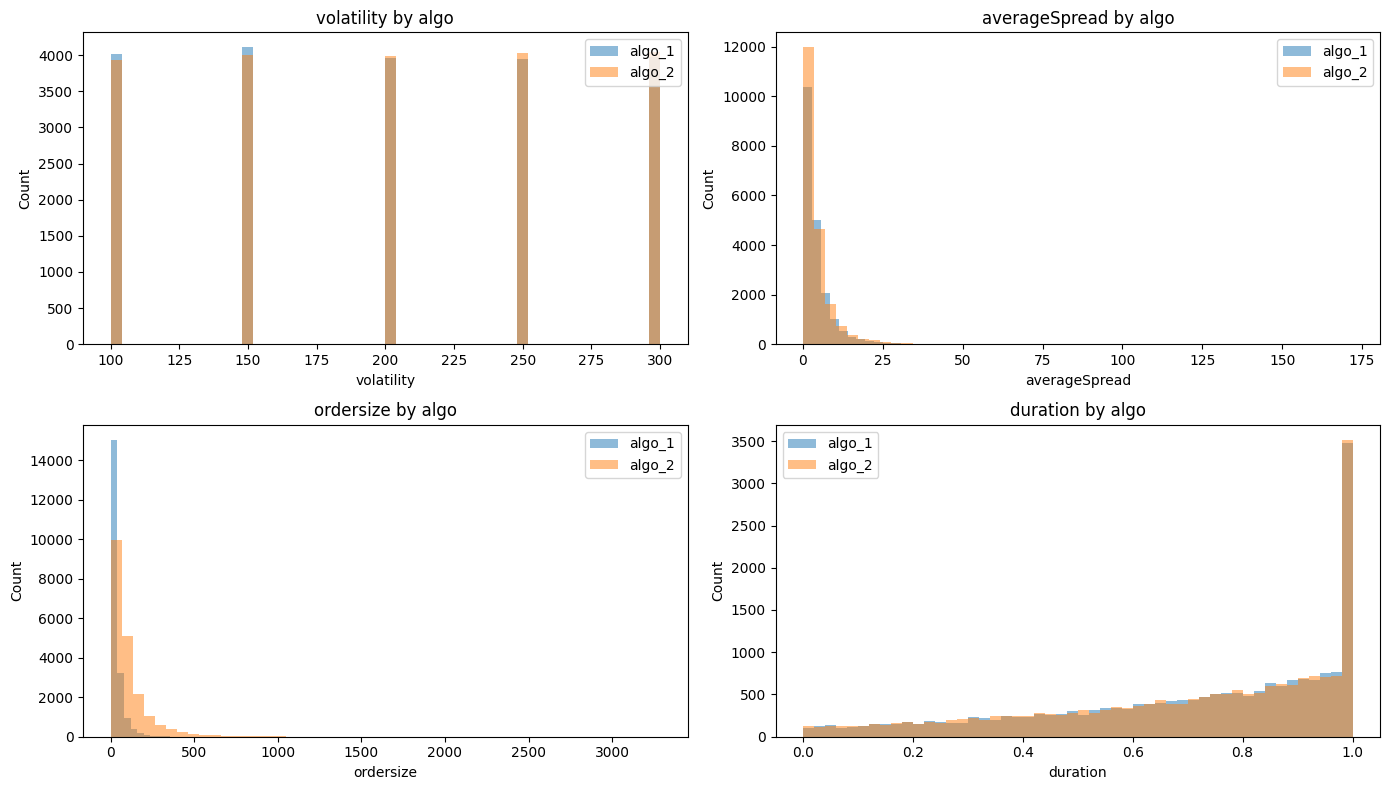

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    for algo_name, sub in df.groupby("algo"):
        ax.hist(sub[feat], bins=50, alpha=0.5, label=algo_name)
    ax.set_title(f"{feat} by algo")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

In [10]:
feature_summary = df.groupby("algo")[features].agg(["mean", "median", "std"])
print(feature_summary)

       volatility                   averageSpread                      \
             mean median        std          mean    median       std   
algo                                                                    
algo_1   199.3625  200.0  70.717527      4.417685  2.706195  5.611367   
algo_2   200.6075  200.0  70.659434      4.447781  2.713522  5.842168   

         ordersize                         duration                      
              mean     median         std      mean    median       std  
algo                                                                     
algo_1   33.547108  20.558415   44.556685  0.704094  0.773792  0.270464  
algo_2  110.651687  67.064684  145.955255  0.700557  0.770492  0.272693  


Volatility is **relatively uniform across the two algos**, though `algo_2` takes on slightly more highly-volatile orders. There is not a lot of variation in volatility values as this measure is discrete and can only take one of five possible values.

Average spread shows a similar right-skewed distribution for both algos, though **`algo_2` has a slightly fatter tail of less liquid orders**. The mid-price normalized spread has a median of close to 3 bps.

Order size shows a right-skewed distribution, and **`algo_2` has a considerably fatter tail of large orders**. `algo_2` tends to handle materially larger orders, with both its mean and median order size several times larger than `algo_1`'s.

Duration shows a similar left-skewed distribution for both algos, with **a significant proportion of orders lasting almost a full day**. The median order lasts around three quarters of a trading day.

Therefore, `algo_2`'s worse slippage can be largely attributed to the nature of the orders it receives. **`algo_2` is systematically assigned larger orders in less liquid names — both of which are well-known drivers of execution shortfall**. It handles a structurally harder flow than `algo_1`, which makes a raw slippage comparison between the two misleading without controlling for order difficulty.

## 4. What do you think is the relationship between the features and IS slippage? (You could start with monotonicity) Model IS slippage as a random variable whose parameters depend on the features. Explain how you determine your model.

- I start with an exploratory monotonicity analysis. This helps see the correlation between IS slippage and each feature and the pattern of such a correlation, if any.

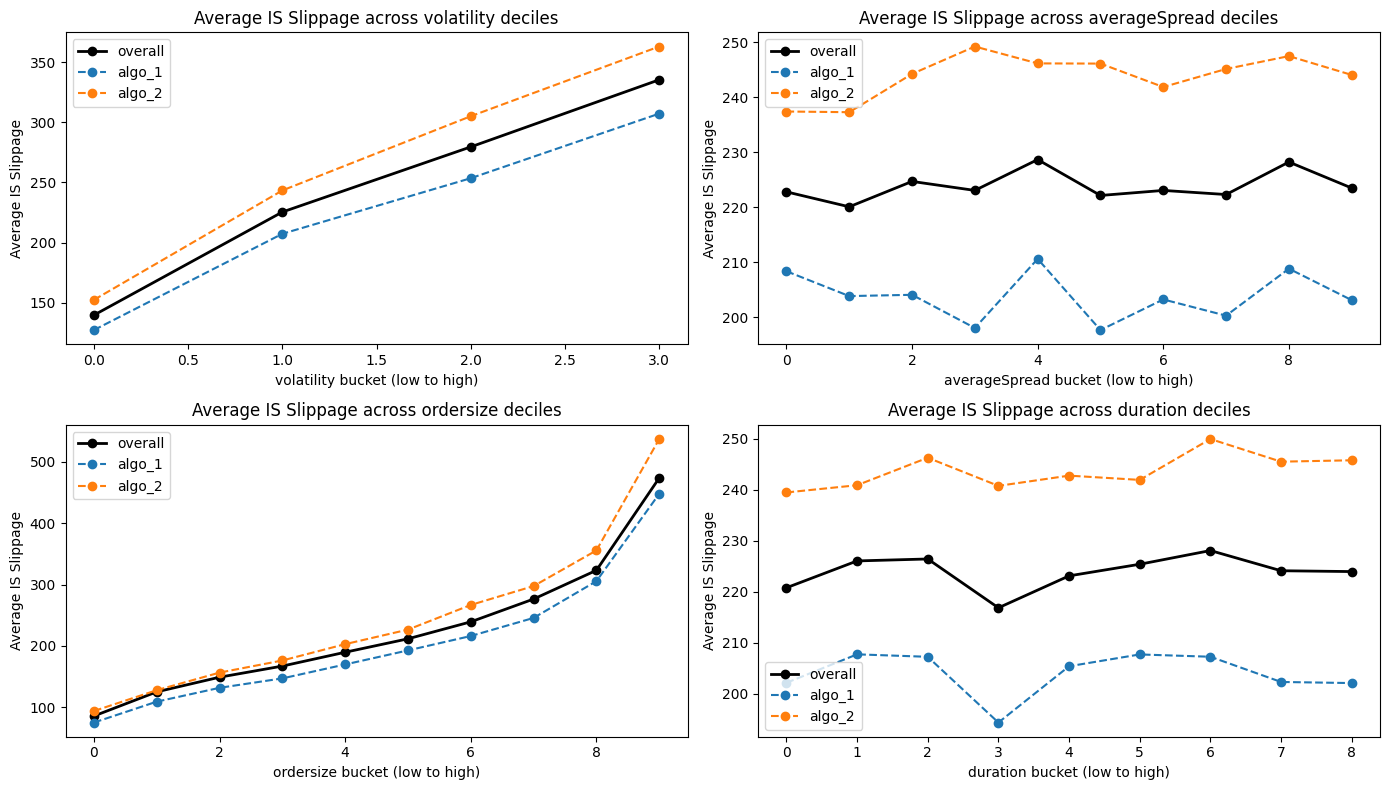

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    # overall line
    temp = df[[feat, "IS_Slippage"]].copy()
    temp["bucket"] = pd.qcut(temp[feat], q=10, duplicates="drop")
    bucket_mean = temp.groupby("bucket")["IS_Slippage"].mean()
    ax.plot(range(len(bucket_mean)), bucket_mean.values, marker="o", 
            color="black", linewidth=2, label="overall")

    # per-algo lines
    for algo_name, sub in df.groupby("algo"):
        temp = sub[[feat, "IS_Slippage"]].copy()
        temp["bucket"] = pd.qcut(temp[feat], q=10, duplicates="drop")
        bucket_mean = temp.groupby("bucket")["IS_Slippage"].mean()
        ax.plot(range(len(bucket_mean)), bucket_mean.values, marker="o", 
                linestyle="--", label=algo_name)

    ax.set_title(f"Average IS Slippage across {feat} deciles")
    ax.set_xlabel(f"{feat} bucket (low to high)")
    ax.set_ylabel("Average IS Slippage")
    ax.legend()

plt.tight_layout()
plt.show()

**Volatility and order size both show a monotonically positive correlation with IS slippage**, where the relationship is nearly linear for volatility and convex for order size — larger orders suffer disproportionately higher slippage.

**Average spread and duration show no clear monotonic relationship with IS slippage**, though there is a slight positive trend for spread at higher deciles.

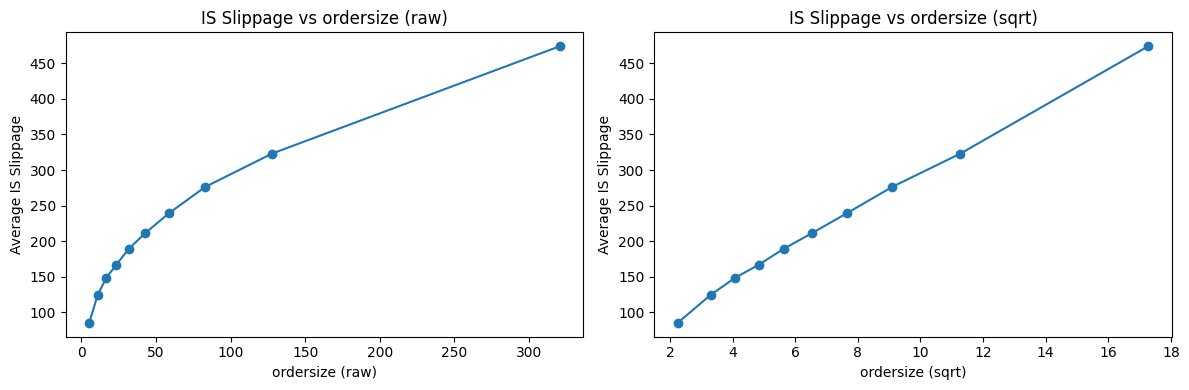

In [12]:
# See how ordersize can be transformed to better fit linear regression assumptions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, feat, title in zip(axes, ["ordersize", "sqrt_ordersize"], ["raw", "sqrt"]):
    temp = df[["IS_Slippage"]].copy()
    temp[feat] = np.sqrt(df["ordersize"]) if feat == "sqrt_ordersize" else df["ordersize"]

    temp["bucket"] = pd.qcut(temp[feat], q=10, duplicates="drop")
    bucket_stats = temp.groupby("bucket", observed=True).agg(
        mean_IS=("IS_Slippage", "mean"),
        mid=(feat, "mean")
    )
    ax.plot(bucket_stats["mid"], bucket_stats["mean_IS"], marker="o")

    ax.set_title(f"IS Slippage vs ordersize ({title})")
    ax.set_xlabel(f"ordersize ({title})")
    ax.set_ylabel("Average IS Slippage")

plt.tight_layout()
plt.show()

Based on the exploratory analysis, I propose the following LASSO regression model: IS = β0 + β1·volatility + β2·sqrt(ordersize) + β3·averageSpread + β4·duration + λ‖β‖₁

- Volatility enters linearly as it shows a near-linear relationship with IS across deciles.
- Order size enters as sqrt(ordersize), consistent with the square root law of market impact, and supported by the near-linear decile plot after transformation.
- Average spread and duration are included linearly as controls despite showing no clear monotonic trend with IS.
- LASSO (L1) regularization is chosen to prevent overfitting as the features could correlate with each other, and the model contains several features whose relevance to IS slippage is uncertain. LASSO's sparsity-inducing penalty allows irrelevant features to be shrunk exactly to zero, effectively performing feature selection alongside estimation.

## 5. Fit your model if possible. How would you interpret your fitting results? Which algo do you think is better? Why?

In [13]:
def summarize_model(model, features, X, y):
    print(f"Model lambda: {model.alpha_:.4f}")
    print("Model coefficients:")
    for feat, coef in zip(features, model.coef_):
        print(f"  {feat}: {coef:.4f}")
    print(f"  intercept: {model.intercept_:.4f}")
    print(f"R²: {model.score(X, y):.4f}")
    print(f'Adjusted R²: {1 - (1 - model.score(X, y)) * (len(y) - 1) / (len(y) - X.shape[1] - 1):.4f}')

### Regression with Only Original Features
Gather some initial trends of each feature with respect to IS slippage.

In [14]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

model_df = df.copy()
model_df['sqrt_ordersize'] = np.sqrt(model_df['ordersize'])

features = ['volatility', 'sqrt_ordersize', 'averageSpread', 'duration']
X = model_df[features]
y = model_df['IS_Slippage']

# standardize so penalty is applied equally across features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso1 = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

summarize_model(lasso1, features, X_scaled, y)

Model lambda: 0.4311
Model coefficients:
  volatility: 78.0600
  sqrt_ordersize: 113.5884
  averageSpread: 0.0131
  duration: 0.2359
  intercept: 223.8795
R²: 0.4929
Adjusted R²: 0.4929


The regression suggests that **higher volatility and larger order size are associated with higher IS slippage while average spread and duration add very little**, which concurs with the preliminary correlation checks. This is economically intuitive as more volatile conditions and larger orders lead to higher execution costs. 

The model achieves an in-sample R² of 0.4929, meaning it explains roughly half of the variation in IS slippage, which indicates a moderate fit. Overall, the results support the view that **execution difficulty is driven primarily by market uncertainty and order size**.

### Regression with Algo Indicator
To compare the two algorithms, I perform another LASSO regression, with the indicator variable `is_algo_1` added besides the aforementioned independent variables.
- Continuous predictors are standardized while the algo indicator is left unscaled. Thus, **the coefficient for each continuous predictors measures the predicted IS slippage/one-standard-deviation increase in the predictor**, and **the coefficient for algo indicator measures the direct slippage difference having accounted for other features**.

In [15]:
model_df['is_algo_1'] = (model_df['algo'] == 'algo_1').astype(int)

feature_unscaled = ['is_algo_1']
X_unscaled = model_df[feature_unscaled]
X_final = np.hstack([X_scaled, X_unscaled])

features += feature_unscaled

lasso2 = LassoCV(cv=5, random_state=42).fit(X_final, y)

summarize_model(lasso2, features, X_final, y)

Model lambda: 0.1145
Model coefficients:
  volatility: 78.6223
  sqrt_ordersize: 133.0899
  averageSpread: 0.4998
  duration: 0.3509
  is_algo_1: 83.3645
  intercept: 182.1972
R²: 0.5285
Adjusted R²: 0.5285


The regression, again, shows that transformed order size is the strongest predictor of slippage, followed by volatility, and average spread and duration contribute very little once the main drivers are included, which is consistent with the earlier analysis.

The coefficient on `is_algo_1` is +83.36, implying that, after controlling for order characteristics and market conditions, `algo_1` experiences about 83 bps more slippage than comparable `algo_2` orders. This suggests that **`algo_2` is the better-performing algorithm on a feature-controlled basis**. 

The model explains about 52.9% of the variation in IS slippage, indicating a moderate fit. This is a slight increase in in-sample adjusted R² from the model without the algo indicator, which confirms that the two algos lead to real IS slippage differences.

# Regression with Interaction Terms
To better understand the algos' performance in different trading conditions, consider the following interaction terms: `is_algo_1 × volatility`, `is_algo_1 × sqrt(ordersize)`, and `volatility × sqrt(ordersize)`.

In [16]:
model_df["is_algo_1 * volatility"] = model_df["is_algo_1"] * X_scaled[:, 0]  # volatility is the first column in X_scaled
model_df['is_algo_1 * sqrt_ordersize'] = model_df["is_algo_1"] * X_scaled[:, 1]  # sqrt_ordersize is the second column in X_scaled
model_df['volatility * sqrt_ordersize'] = X_scaled[:, 0] * X_scaled[:, 1]  # interaction between volatility and sqrt_ordersize

features_interactions = ["is_algo_1 * volatility", "is_algo_1 * sqrt_ordersize", "volatility * sqrt_ordersize"]
X_all = np.hstack([X_final, model_df[features_interactions].values])

features += features_interactions

lasso3 = LassoCV(cv=5, random_state=42).fit(X_all, y)

summarize_model(lasso3, features, X_all, y)

Model lambda: 0.1145
Model coefficients:
  volatility: 63.6482
  sqrt_ordersize: 117.2762
  averageSpread: 0.1828
  duration: 0.0200
  is_algo_1: 98.2180
  is_algo_1 * volatility: 30.1595
  is_algo_1 * sqrt_ordersize: 63.4224
  volatility * sqrt_ordersize: 46.6193
  intercept: 189.2099
R²: 0.5881
Adjusted R²: 0.5880


The regression suggests that the difference in the algos is not constant across trading conditions. 

The coefficient on `is_algo_1` is +98.22, which is an increase from before, meaning an even more pronounced gap from `algo_2` on average. The positive interaction between `is_algo_1` and volatility and that between `is_algo_1` and order size shows that **`algo_1` becomes especially worse in volatile conditions and large orders**. Additionally, the positive interaction between volatiltiy and order size means that **large orders are particularly costly when market is volatile**.

The model explains about 58.8% of the variation in IS slippage, indicating a moderate fit. This is an increase in in-sample adjusted R² from the model with algo indicator, which confirms that these interactions are economically important.

### Homoscedasticity Check

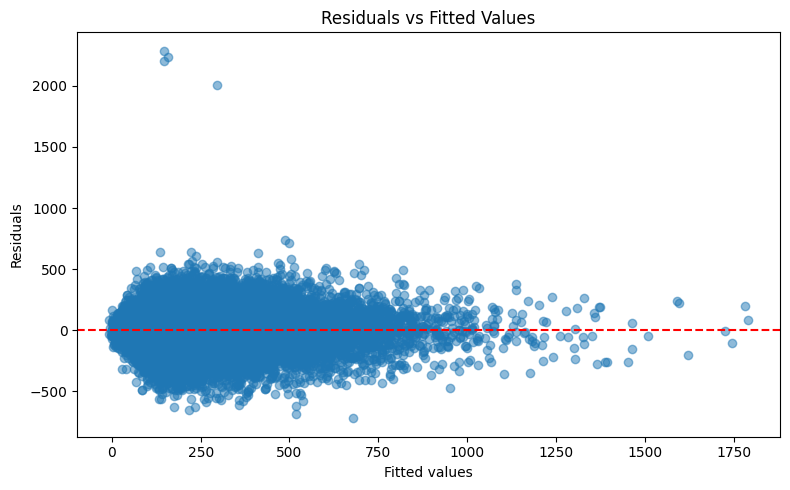

In [17]:
fitted = lasso3.predict(X_all)
residuals = y - fitted

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

The residuals vs fitted plot suggests **some heteroskedasticity**, since the vertical spread of the residuals is not constant across the fitted range (appears larger for lower fitted values). However, this does not invalidate the model; it mainly *affects standard errors and inference under ordinary OLS assumptions*.

To address this, I refit the same specification using OLS with HC3 heteroskedasticity-robust standard errors.

In [18]:
import statsmodels.api as sm

X_df = pd.DataFrame(X_all, columns=features)
X_df = sm.add_constant(X_df)

ols_sameX = sm.OLS(y, X_df).fit(cov_type="HC3")
print(ols_sameX.summary())

                            OLS Regression Results                            
Dep. Variable:            IS_Slippage   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     7015.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:12:01   Log-Likelihood:            -2.5050e+05
No. Observations:               40000   AIC:                         5.010e+05
Df Residuals:                   39991   BIC:                         5.011e+05
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

The OLS results are directionally almost identical to the Lasso results, and the key coefficients remain highly significant, which strengthens confidence in the main insights. Therefore, **the core conclusions of the model appear robust to heteroskedasticity**.

** The reported p-values should be interpreted as supportive/descriptive evidence for the selected specification rather than as strict inference from a model fixed completely in advance.

### Out-of-sample Robustness Check
I also evaluate the selected interaction specification out of sample using a train/test split. This additional step complements the main analysis above by **checking whether the model fit and the relative advantage of `algo_2` remain stable on unseen data**.
- I fit the scaler only on the training set, create the interaction terms from the training-scaled variables, fit `LassoCV` only on the training set, and then evaluate performance on the held-out test set.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

# fresh copy so this section is self-contained
tt_df = df.copy()
tt_df["sqrt_ordersize"] = np.sqrt(tt_df["ordersize"])
tt_df["is_algo_1"] = (tt_df["algo"] == "algo_1").astype(int)

y = tt_df["IS_Slippage"].values

cont_cols = ["volatility", "sqrt_ordersize", "averageSpread", "duration"]
dummy_cols = ["is_algo_1"]

train_idx, test_idx = train_test_split(np.arange(len(tt_df)), test_size=0.2, random_state=42)

train_df = tt_df.iloc[train_idx].copy()
test_df = tt_df.iloc[test_idx].copy()

scaler_tt = StandardScaler()
X_train_cont = scaler_tt.fit_transform(train_df[cont_cols])
X_test_cont = scaler_tt.transform(test_df[cont_cols])

X_train_dummy = train_df[dummy_cols].values
X_test_dummy = test_df[dummy_cols].values

train_vol, train_size, train_spread, train_duration, train_algo = X_train_cont[:, 0], X_train_cont[:, 1], X_train_cont[:, 2], X_train_cont[:, 3], X_train_dummy[:, 0]
test_vol, test_size, test_spread, test_duration, test_algo = X_test_cont[:, 0], X_test_cont[:, 1], X_test_cont[:, 2], X_test_cont[:, 3], X_test_dummy[:, 0]

feature_names_tt = ["volatility", "sqrt_ordersize", "averageSpread", "duration", "is_algo_1",
                    "is_algo_1 * volatility", "is_algo_1 * sqrt_ordersize", "volatility * sqrt_ordersize"]

X_train_all = np.column_stack([train_vol, train_size, train_spread, train_duration, train_algo, 
                                train_algo * train_vol, train_algo * train_size, train_vol * train_size])

X_test_all = np.column_stack([test_vol, test_size, test_spread, test_duration, test_algo,
                                test_algo * test_vol, test_algo * test_size, test_vol * test_size])

y_train = train_df["IS_Slippage"].values
y_test = test_df["IS_Slippage"].values

lasso_tt = LassoCV(cv=5, random_state=42).fit(X_train_all, y_train)

y_train_pred = lasso_tt.predict(X_train_all)

print('***** Training Set Performance *****')
summarize_model(lasso_tt, feature_names_tt, X_train_all, y_train)
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred):.4f}")
print('-----------------------------------------------------------------------------------------------------------------')

y_test_pred = lasso_tt.predict(X_test_all)

print()
print('***** Test Set Performance *****')
print(f"R²:  {r2_score(y_test, y_test_pred):.4f}")
print(f"Adjusted R²: {1 - (1 - r2_score(y_test, y_test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test_all.shape[1] - 1):.4f}")
print(f"RMSE:  {root_mean_squared_error(y_test, y_test_pred):.4f}")

***** Training Set Performance *****
Model lambda: 0.1149
Model coefficients:
  volatility: 63.6477
  sqrt_ordersize: 117.2681
  averageSpread: 0.0000
  duration: 0.0589
  is_algo_1: 98.2574
  is_algo_1 * volatility: 30.3927
  is_algo_1 * sqrt_ordersize: 64.1033
  volatility * sqrt_ordersize: 46.8357
  intercept: 189.1016
R²: 0.5920
Adjusted R²: 0.5919
RMSE: 126.4727
-----------------------------------------------------------------------------------------------------------------

***** Test Set Performance *****
R²:  0.5723
Adjusted R²: 0.5718
RMSE:  128.6321


### Multicollinearity Check

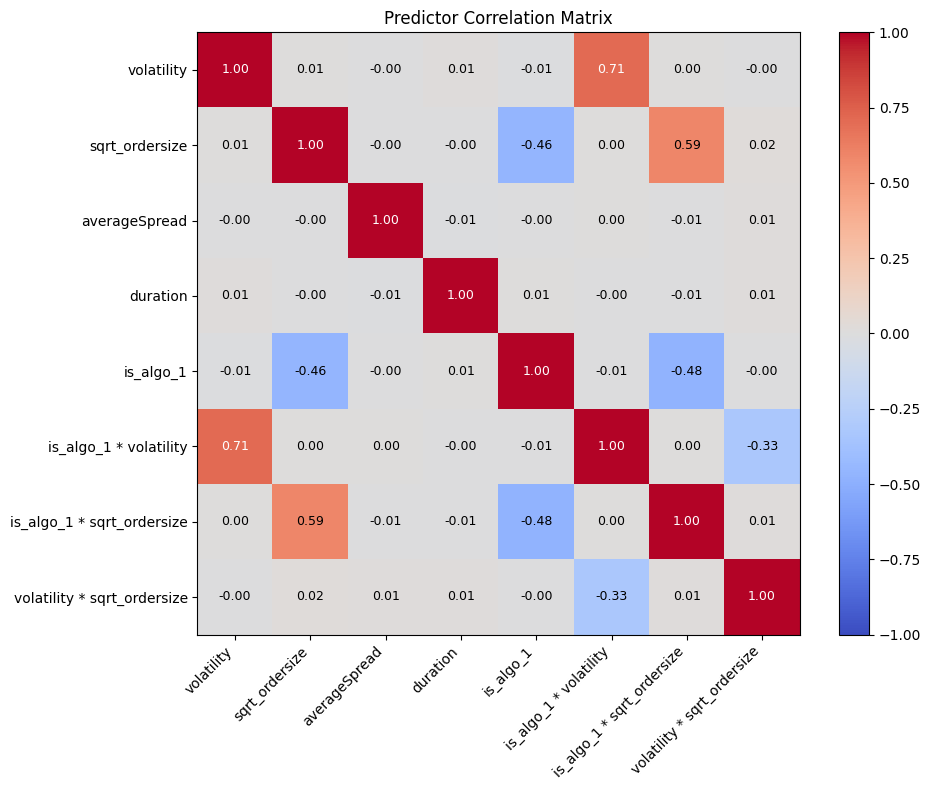

In [20]:
predictors = model_df[features]

corr_matrix = predictors.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(im)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# annotate cells
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center',
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.6 else 'black',
                fontsize=9)

ax.set_title('Predictor Correlation Matrix')
plt.tight_layout()
plt.show()

The predictor correlation matrix **does not show severe multicollinearity among the main effects**. 
- Most of the original predictors are only weakly correlated, with the main exception that `sqrt_ordersize` and `is_algo_1` are moderately negatively correlated, indicating that, again, **the two algos are assigned somewhat different order-size mixes**.
- The interaction terms are more correlated with their corresponding main effects, especially volatility with `is_algo_1 * volatility` and `sqrt_ordersize` with `is_algo_1 * sqrt_ordersize`. This is a common feature of interaction models rather than a modeling error. By using Lasso regularization, the model is less sensitive to this issue than ordinary least squares would be. 

Therefore, I interpret **the model and coefficient magnitudes mainly as evidence about relative predictor importance and conditional algo performance, rather than as exact coefficient-level causal inference**.

### Conclusion
**`algo_2` is generally a better trading algorithm than `algo_1`**. Even though on a raw unconditional basis, `algo_1` appears to have lower IS slippage, this comparison is not fully fair because the two algos are not handling identical orders under identical market conditions. `algo_2` performs better once order difficulty and market conditions are controlled for, and especially after adding algo indicator and interaction terms. In other words, with other factors fixed, `algo_2` is expected to execute comparable orders with lower slippage, and **its relative advantage becomes even stronger in more difficult settings such as large orders and high-volatility conditions**.

## 6. What if some orders are partially filled? (Hint: Construct an algo that may not fully fill but always beats arrival mid) How would you compare two algos when one algo requires fully fill while the other does not?

An algo that does not require full fill **should not be compared to a full-fill algorithm using filled-price slippage alone** because the former can trivially decrease IS slippage: if the price moves adversely, simply cancel the remaining quantity. Only the fills executed before the adverse move are counted, so the reported IS looks artificially good. A fully-filling algo must complete an order regardless of price; a partially-filling algo can cherry-pick favorable executions and abandon the rest.

For example, an algo that places a passive limit order at arrival mid and cancels if the price moves away will only fill when the price comes to it, guaranteeing a negative or zero IS on every fill by construction. But this leaves a potentially large unfilled residual.

To compare them fairly, we could try:
- **Penalize unfilled quantity**: assign the unfilled shares the closing price (or VWAP) as a punitive benchmark. This forces the partial algo to account for the cost of not filling.
- **Fill rate as a separate metric**: report fill rate alongside IS so a reader can see the tradeoff between slippage and completion. An algo with 5 bps IS and 60% fill rate is not comparable to one with 15 bps IS and 100% fill rate without surfacing both numbers.
- **Opportunity cost adjustment**: measure the P&L the desk missed on unfilled shares, and add it to the algo's total cost.

When fill rates differ, IS must be accompanied by a completion-adjusted cost that penalizes leaving quantity behind.

## 7. Describe how you would tackle this problem if you have access to more features. What features do you think might help?

If I had access to more features, I would especially want to add **timing, order book microstructure, and execution style** variables.
- Timing: the time of day and day of week when the order arrives. **Market conditions vary systematically across time**. For example, volatility and price movement are often higher near the open and close, and trading conditions may also differ across weekdays. If one algo receives more orders during difficult periods, its slippage may look worse even if the algo itself is not inferior.
- Order Book Microstructure: features such as depth across multiple price levels and order book imbalance. Even if the best bid and ask look favorable at arrival, **execution can still be costly if there is not enough volume available near the mid-price**. A shallow or imbalanced order book may force the algo to trade through several price levels, increasing slippage.
- Execution Style: features such as participation-rate target, order aggressiveness, and average time between child orders. These choices directly affect market impact. All else equal, **an algo that trades more aggressively, crosses the spread more often, or submits child orders more frequently is likely to increase immediate execution** cost through spread crossing and market impact, **but it can reduce timing risk** by finishing the order faster.

These features would help separate true algo quality from differences in market conditions and execution instructions, leading to a fairer comparison of the two algos.

### AI Use Disclosure
I used AI as a support tool mainly to look up some Python syntax and refine modeling choices and interpretation. I validated the suggestions against the assignment definition, exploratory plots, and regression outputs.

*e.g., Keeping the algo indicator unstandardized*
- **Prompt used:** “How to change the code so that indicator variable doesnt get standardized.”
- **AI suggestion:** Standardize only the continuous predictors (`volatility`, `sqrt_ordersize`, `averageSpread`, `duration`) while leaving the binary algo indicator (`is_algo_1`) unscaled.
- **Validation:** I reran the model with this revised specification and confirmed that the interpretation became clearer: the continuous-feature coefficients could be read as effects of a one-standard-deviation increase, while the `is_algo_1` coefficient could be read directly as the conditional slippage difference in bps between the two algos. This made the model output more economically interpretable and more appropriate for answering which algo performs better after controls.

*e.g., Refining Q5 with interaction terms*
- **Prompt used:** “I want to refine my Q5. What interaction terms should I include?”
- **AI suggestion:** Add `is_algo_1 × volatility`, `is_algo_1 × sqrt_ordersize`, and `volatility × sqrt_ordersize` to test whether the algo gap changes under harder trading conditions.
- **Validation:** I validated this by checking the Q4 exploratory plots, which showed that volatility and order size were the strongest drivers of slippage. I then fit the interaction model and found that the fit improved meaningfully (`R²` increased from `0.5285` to `0.5881`), and the estimated coefficients were economically sensible: the gap against `algo_1` widened in higher-volatility and larger-order settings. This confirmed that the interaction terms were useful rather than arbitrary.

### Internship Availability
*I'm available for the internship starting June 1st to September 26th and can come to office 5 days/week. Thank you!*